In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update(
    {
        # "mathtext.fontset": "stix",
        # "font.family": "STIXGeneral",
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "axes.labelsize": 20,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
    }
)

In [3]:
exp_name = "pi05_fold_towel_0109"
x_t = np.load(f"../data/study/{exp_name}_x_t.npy")
n_steps = x_t.shape[1] - 1

print(x_t.shape, n_steps)

(200, 11, 50, 14) 10


In [4]:
# constant time schedule
times = np.linspace(1, 0, n_steps + 1)[:-1]
dt = -1 / n_steps
# estimate x_1 from x_t and the time schedule
x_1_hat = x_t[:, :-1] - times.reshape(1, -1, 1, 1) * (np.diff(x_t, axis=1)) / dt

x_t_final = x_t[:, -1:]
diff_x1_hat = np.linalg.norm(x_1_hat - x_t_final, axis=-1)
diff_x1_hat_avg = np.mean(diff_x1_hat, axis=(0))

print(diff_x1_hat_avg.shape)

(10, 50)


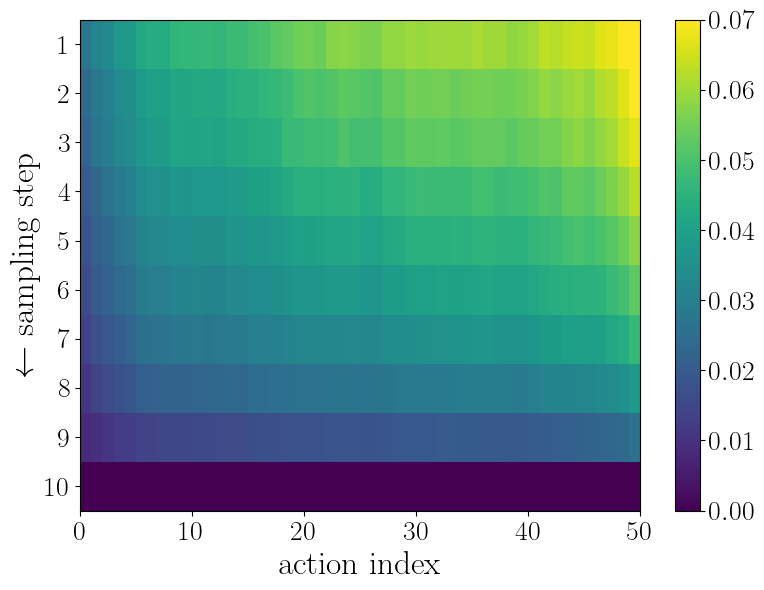

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
n_rows, n_cols = diff_x1_hat_avg.shape
im = ax.imshow(diff_x1_hat_avg, aspect="auto", extent=[0, n_cols, n_rows - 0.5, -0.5])
ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels(np.arange(1, n_rows + 1))
im.set_clim(vmin=0, vmax=0.07)
ax.set_xlabel("action index", fontsize=24)
ax.set_ylabel(r"$\leftarrow$ sampling step", fontsize=24)
# ax.set_title("(b)", fontsize=28, loc="center", y=-0.3)
fig.colorbar(im, ax=ax, shrink=1)
plt.tight_layout()
plt.savefig(f"../data/study/{exp_name}_x1.png")

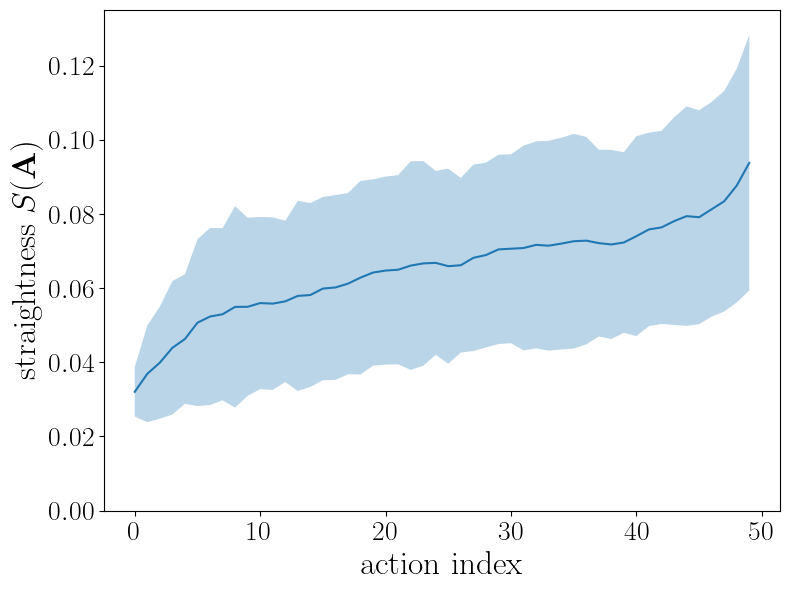

In [12]:
def straightness(x):
    d = x[:, :1] - x[:, -1:]
    s = np.linalg.norm(d - np.diff(x, axis=1) / dt, axis=-1)
    return np.mean(s, axis=1)


stra = straightness(x_t)
stra_avg = np.mean(stra, axis=0)
stra_std = np.std(stra, axis=0)

x = np.arange(len(stra_avg))
plt.figure(figsize=(8, 6))
plt.plot(x, stra_avg, label="mean")
plt.fill_between(x, stra_avg - stra_std, stra_avg + stra_std, alpha=0.3)

# p_05 = np.percentile(stra, 5, axis=0)
# p_95 = np.percentile(stra, 95, axis=0)

# x = np.arange(len(stra_avg))
# plt.figure(figsize=(7, 6))
# plt.plot(x, stra_avg, label="mean")
# plt.fill_between(x, p_05, p_95, alpha=0.3)

plt.ylim(0, 0.135)
plt.xlabel("action index", fontsize=24)
plt.ylabel(r"straightness $S(\mathbf{A})$", fontsize=24)
# plt.title("(c)", fontsize=28, loc="center", y=-0.3)
plt.tight_layout()
plt.savefig(f"../data/study/{exp_name}_stra.png")